# **CUSTOMER BEHAVIOUR & CHURN ANALYSIS**

#### **Programme** :  Data Analytics Internship AnalystLab Africa
#### **Week** : Week 01

ABC Communications Ltd is seeking to understand the factors associated with customer churn and identify opportunities to improve customer retention.

Customer churn refers to customers discontinuing their relationship with the company. From a business perspective, understanding which customer groups have a higher churn can help management prioritize retention efforts and investigate potential causes of customer loss.

This is a notebook of an analytical process seeking to understand the above problematic, from cleaning to recommendations. 

This analysis aims to understand the composition of the customer base, identify customer segments with higher churn, assess the relationship between contract type and retention, examine whether tenure is associated with customer loyalty, analyze churn across different services, compare churn across payment methods, develop actionable recommendations for improving customer retention.

## 1. Data Loading & Inspection
The analysis uses Pandas and Numpy for data manipulation and numerical analysis, while Matplotlib and Seaborn are used to create visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [89]:
sns.set_theme(
    style="whitegrid",
    context="notebook"
)
plt.rcParams["figure.figsize"]= (10,6)
plt.rcParams["axes.titlesize"]= 16
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["xtick.labelsize"]= 10
plt.rcParams["ytick.labelsize"]= 10
plt.rcParams["figure.dpi"]= 100

In [2]:
df= pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

The Telco Customer Churn dataset contains customer demographic information, tenure, subscribed methods and billing information. The dataset will first be inspected to understand its structure, variable types and overall quality before performing the exploratory analysis.

In [3]:
df_raw = df.copy()

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1793,4193-IBKSW,Male,0,Yes,Yes,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),24.75,1769.6,No
6868,1195-OIYEJ,Male,0,No,No,13,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,91.10,1135.7,Yes
4107,2190-PHBHR,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,No,No,No,Yes,Two year,Yes,Credit card (automatic),94.45,6921.7,No
1683,0354-VXMJC,Male,0,Yes,Yes,23,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.60,426.65,No
2637,7665-NKLAV,Female,0,Yes,Yes,36,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,Two year,No,Credit card (automatic),40.65,1547.35,No


In [8]:
df.shape

(7043, 21)

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The dataset contains 7,043 customer records and 21 variables covering demographic characteristics, customer tenure, subscribed services, contract details, payment methods, and billing information.

## 2. Data Cleaning

The cleaning focuses on data types, missing values, duplicate records,unique categorical values, numerical summary statistics, potential inconsistencies in categorical and numerical fields.

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

No duplicate rows were identified so no records were removed at this stage.

In [22]:
df["TotalCharges"].dtype

dtype('float64')

In [14]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [20]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [23]:
df_raw.loc[df["TotalCharges"].isna(), ["customerID","tenure", "MonthlyCharges", "TotalCharges"]]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [25]:
df.loc[df["TotalCharges"].isna() & (df["tenure"] == 0), "TotalCharges"] = 0

In [26]:
df["TotalCharges"].isna().sum()

np.int64(0)

The initial missing-value check did not identify missing values. However, further inspection of the TotalCharges column revealed 11 values containing whitespace rather than valid numerical values. Since whitespace is stored as text, these observations were not initially identified by the standard missing-value check. The TotalCharges column was converted from object to numeric using appropriate type conversion. The 11 whitespace values were consequently converted to NaN.

Further investigation showed that all 11 affected customers had a tenure of 0 months. Since these customers had not yet accumulated monthly charges, their TotalCharges values were treated as 0 rather than replacing them with a statistical estimate such as the median. 

This cleaning decision preserves the business meaning of the records rather than artificially assigning an average total charge.

In [27]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [29]:
df["DeviceProtection"].value_counts()

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

In [30]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [31]:
df["MultipleLines"].value_counts()²

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [32]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [33]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [36]:
text_columns = df.select_dtypes(include = "object").columns
for col in text_columns :
    whitespace_count = df[col].str.fullmatch(r"\s*", na=False).sum()

Categorical variables were examined using frequency counts and unique-value checks to identify unexpected categories, spelling inconsistencies, case differences, or hidden whitespace. Service-related variables contain categories such as Yes, No and No internet service. These categories were retained because they represent different customer states.

## 3. Customer Base Analysis

In [37]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


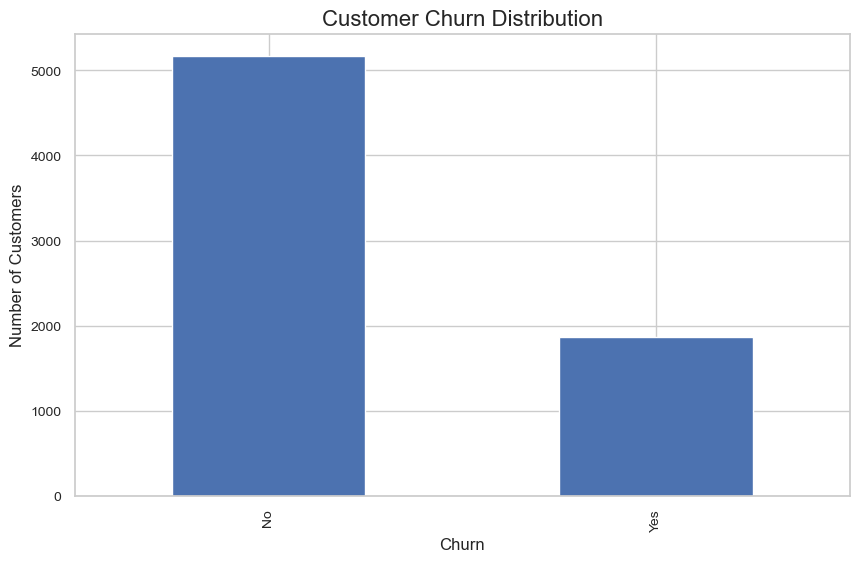

In [90]:
df["Churn"].value_counts().plot(
    kind="bar",
    title="Customer Churn Distribtion"
)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

Eventhough the amount of customers not churning is high, the churning proportion is not negligible.

In [43]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


### 3.1 Contract Distribution
This analysis compares the proportion of customers who churn within each contract category. The objective is to determine whether contract structure is associated with customer retention.

In [114]:
contract_counts = df["Contract"].value_counts()

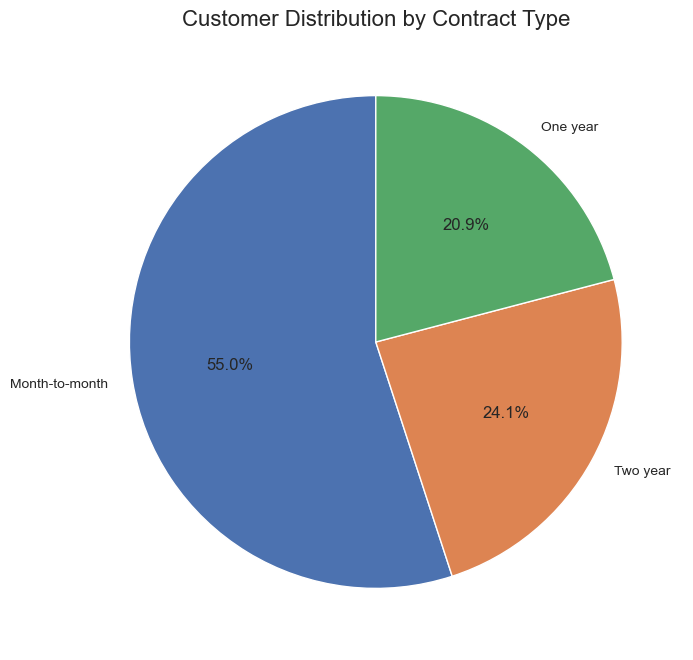

In [115]:
plt.figure(figsize=(8,8))
plt.pie(
    contract_counts,
    labels=contract_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Customer Distribution by Contract Type")
plt.tight_layout
plt.show()

Month-to-month contracts represent the largest share of the customer base, accounting for 55% of customers.

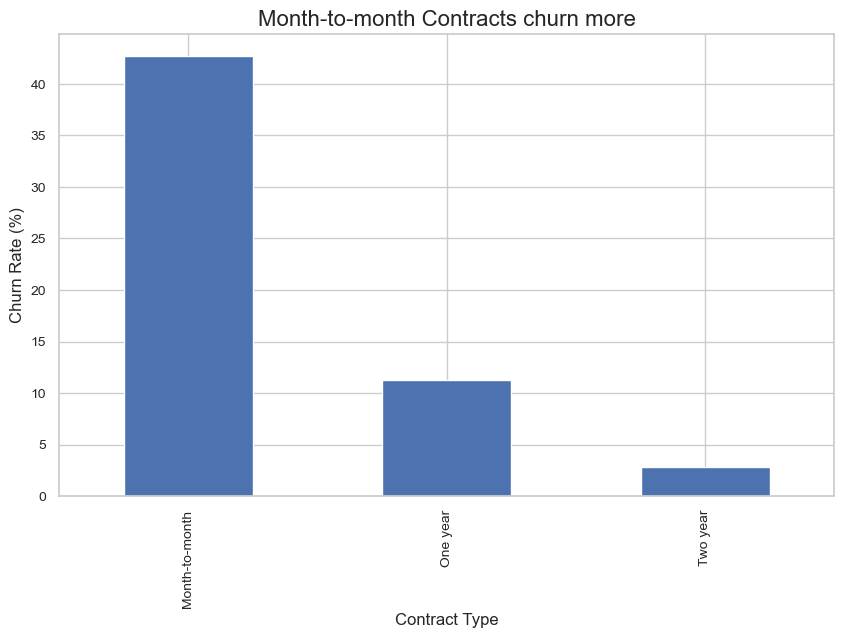

In [112]:
contract_churn["Yes"].plot(
    kind="bar",
    title="Month-to-month Contracts churn more"
)
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

The large proportion of month-to-month customers is important because these customers have less long-term contractual commitment and therefore represent an important segment for retention initiatives.

### 3.2 Service Distribution 

In [45]:
phoneservice_churn = pd.crosstab(df["PhoneService"], df["Churn"], normalize="index") * 100
print(phoneservice_churn)

Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637


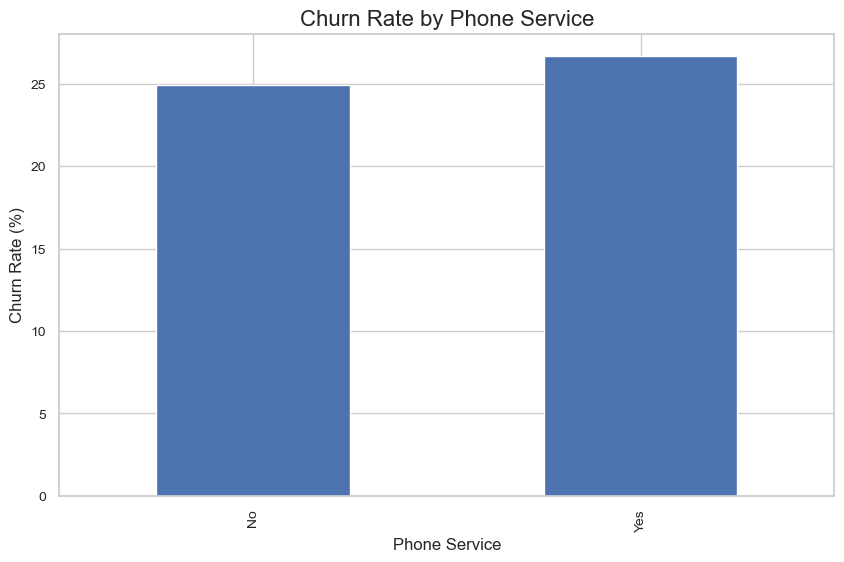

In [92]:
phoneservice_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by Phone Service"
)
plt.xlabel("Phone Service")
plt.ylabel("Churn Rate (%)")
plt.show()

Phone service does not strongly impact churn rate.

In [48]:
multiplelines_churn = pd.crosstab(df["MultipleLines"], df["Churn"], normalize="index") * 100
print(multiplelines_churn)

Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896


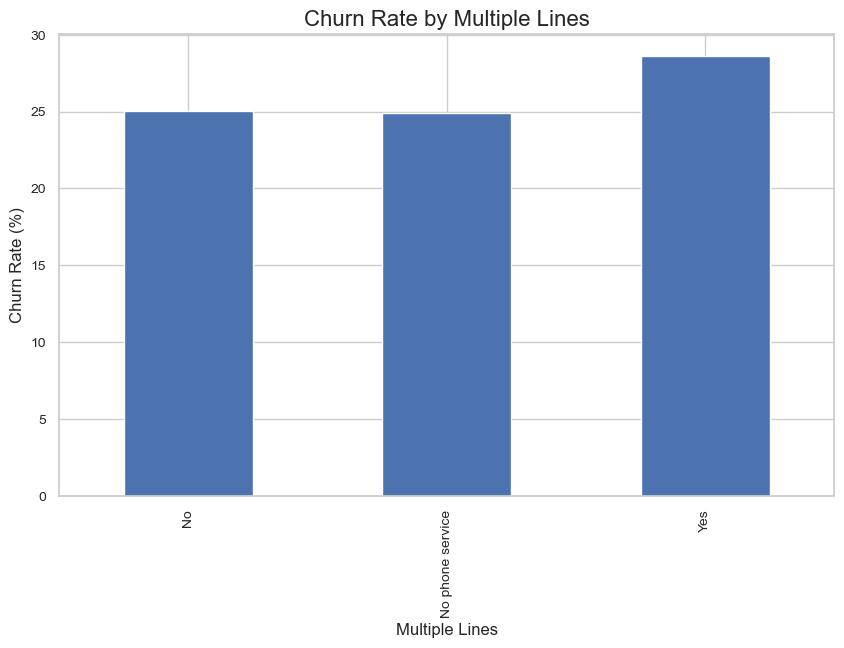

In [93]:
multiplelines_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by Multiple Lines"
)
plt.xlabel("Multiple Lines")
plt.ylabel("Churn Rate (%)")
plt.show()

Customers having multiple lines tend to churn slightly more than those either having a single line or no phone service at all.

In [51]:
internetservice_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
print(internetservice_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


In [116]:
internet_counts = df["InternetService"].value_counts()

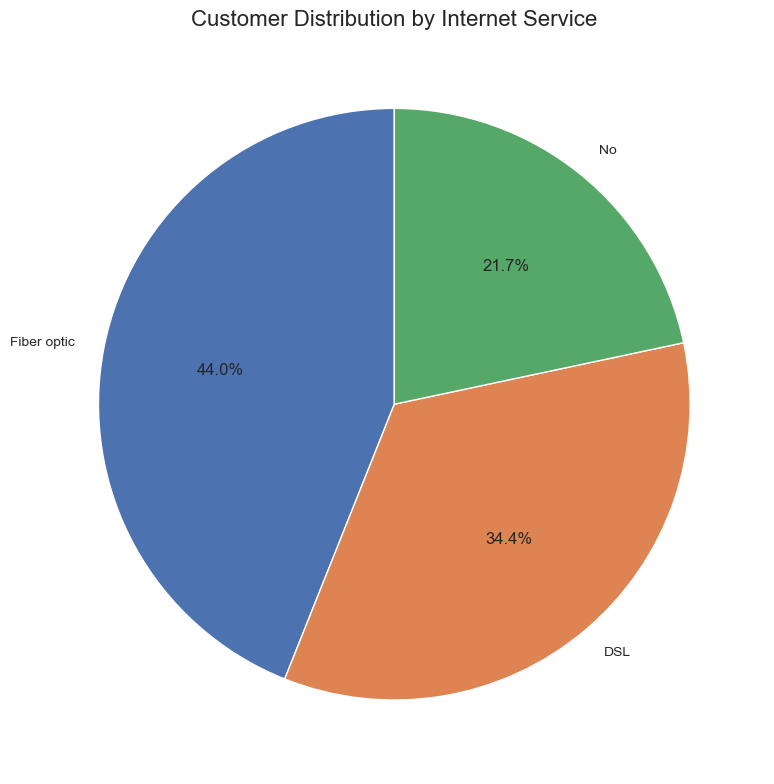

In [117]:
plt.figure(figsize=(8,8))
plt.pie(
    internet_counts,
    labels=internet_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Customer Distribution by Internet Service")
plt.tight_layout()
plt.show()

Fiber optic is the most used internet service category, representing approximately 44% of the customer base.

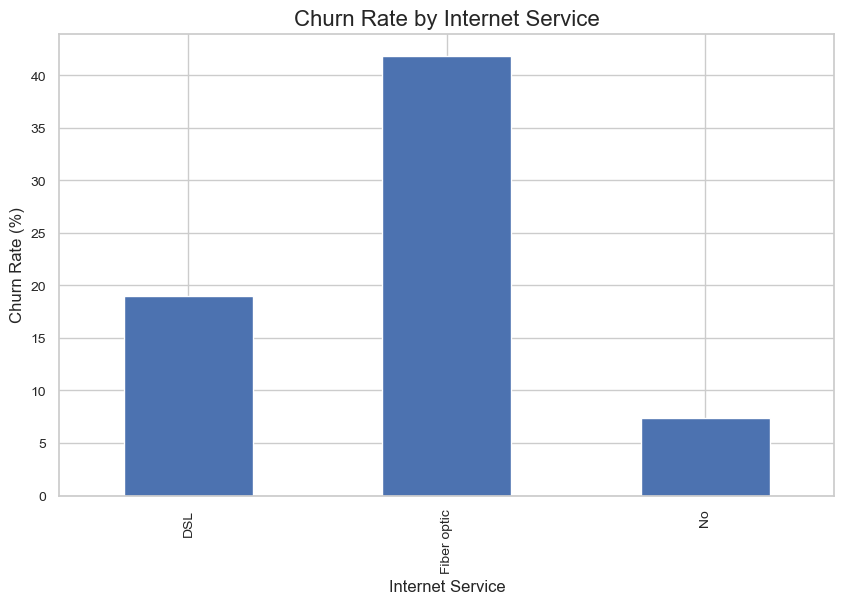

In [94]:
internetservice_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by Internet Service"
)
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

Because fiber optic customers also show a substantially higher churn rate, this large customer segment represents an important area for management to investigate further.

In [53]:
onlinesecurity_churn = pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index") * 100
print(onlinesecurity_churn)

Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


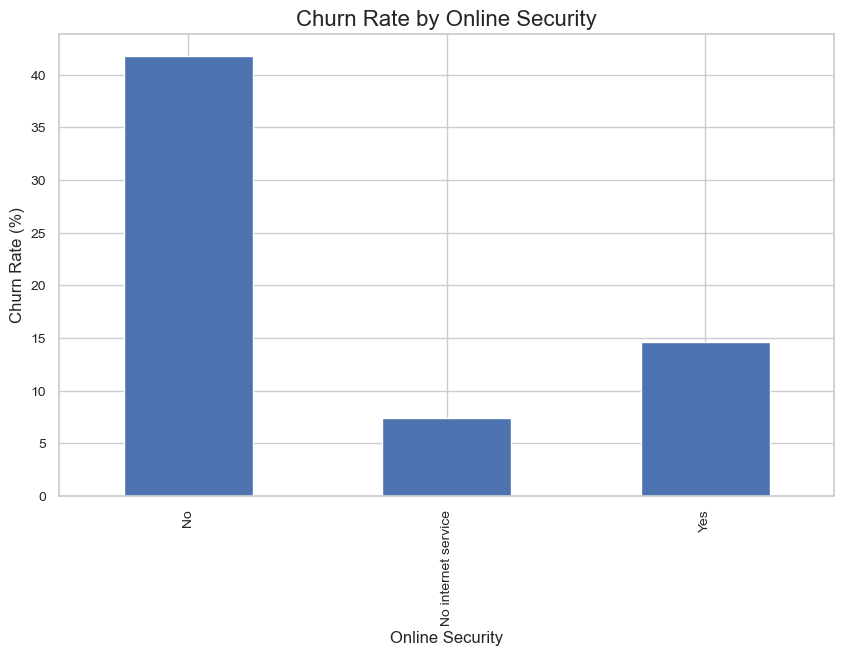

In [95]:
onlinesecurity_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by Online Security"
)
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.show()

Customers not having an online security tend to churn way more than those having the online security or no internet service at all.

In [55]:
onlinebackup_churn = pd.crosstab(df["OnlineBackup"], df["Churn"], normalize="index") * 100
print(onlinebackup_churn)

Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494


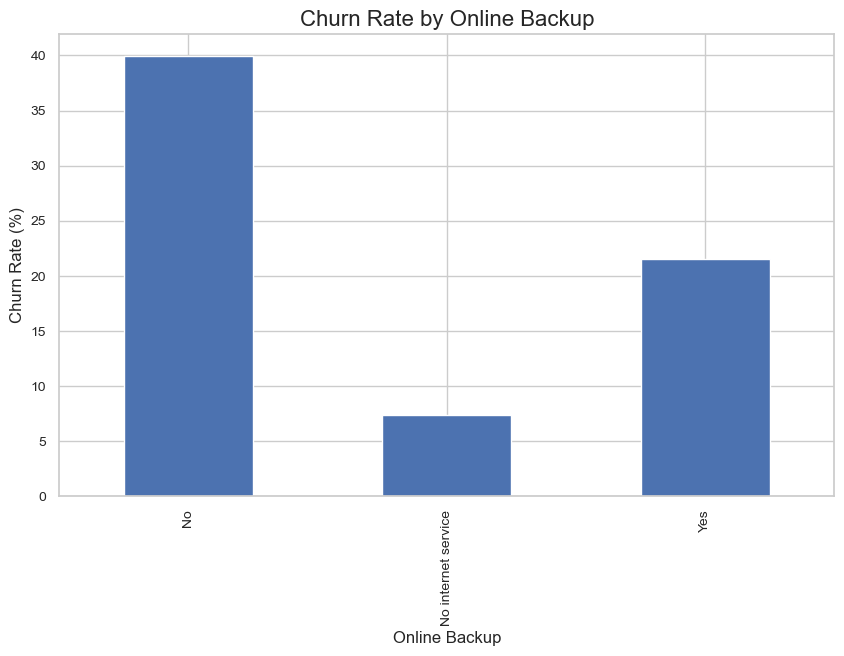

In [96]:
onlinebackup_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by Online Backup"
)
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.show()

Customers not having an online backup tend to churn way more than those having the online backup or no internet service at all.

In [57]:
deviceprotection_churn = pd.crosstab(df["DeviceProtection"], df["Churn"], normalize="index") * 100
print(deviceprotection_churn)

Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064


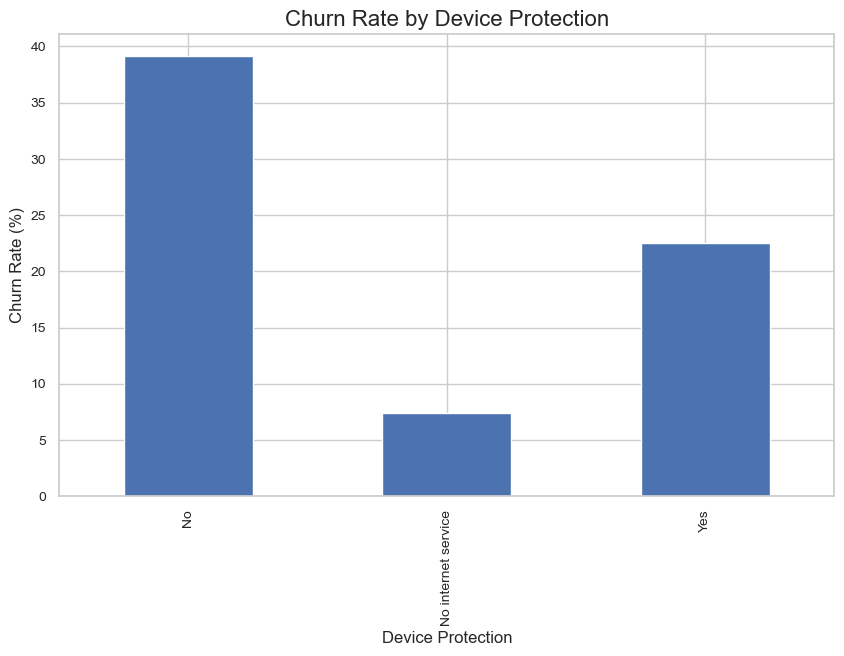

In [97]:
deviceprotection_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by Device Protection"
)
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.show()

Customers not having a device protection tend to churn way more than those having the protection  or no internet service  at all.

In [59]:
techsupport_churn = pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100
print(techsupport_churn)

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


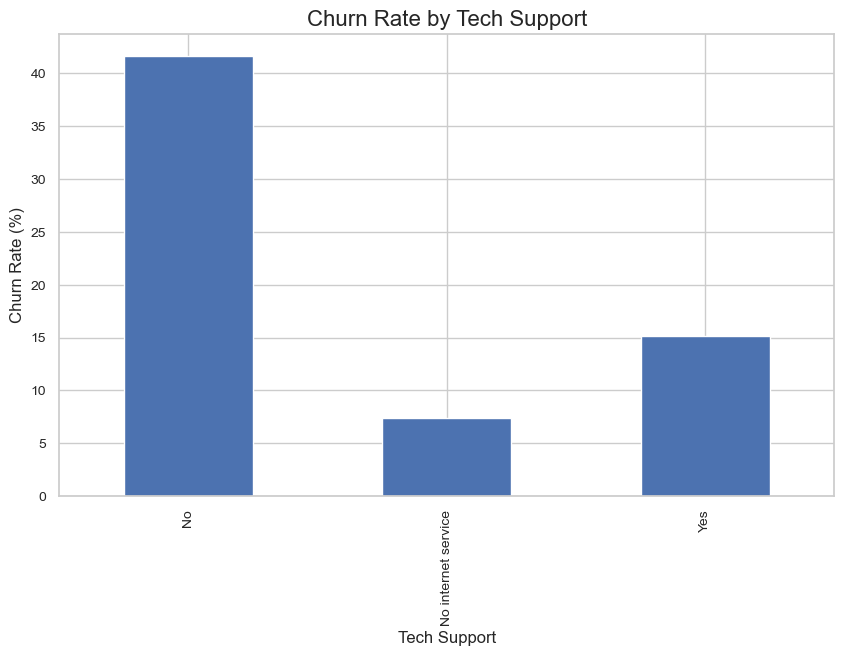

In [98]:
techsupport_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by Tech Support"
)
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.show()

Customers not having a tech support  tend to churn way more than those having the support  or no internet service  at all.

In [61]:
streamingtv_churn = pd.crosstab(df["StreamingTV"], df["Churn"], normalize="index") * 100
print(streamingtv_churn)

Churn                       No        Yes
StreamingTV                              
No                   66.476868  33.523132
No internet service  92.595020   7.404980
Yes                  69.929812  30.070188


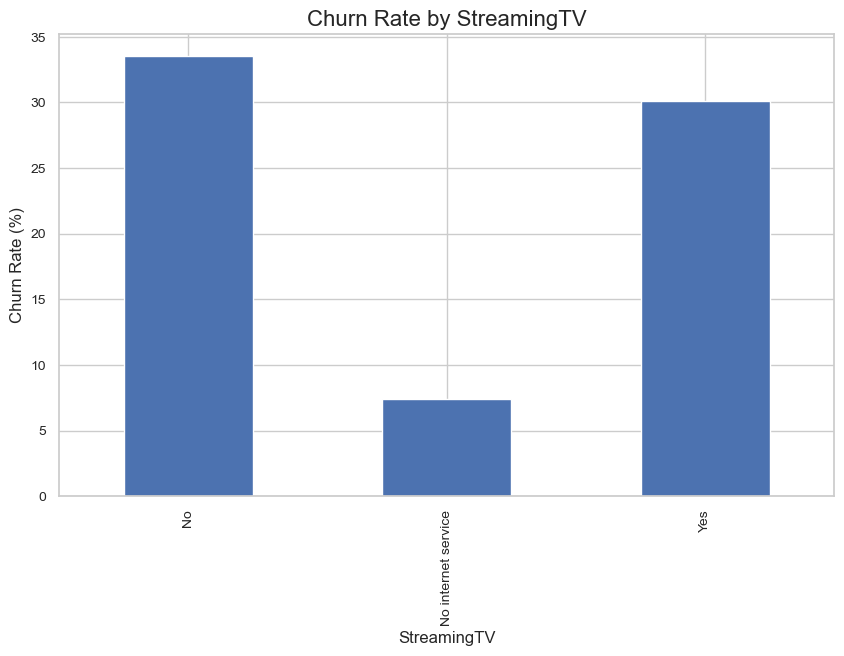

In [99]:
streamingtv_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by StreamingTV"
)
plt.xlabel("StreamingTV")
plt.ylabel("Churn Rate (%)")
plt.show()

Customers who do not stream TV tend to churn slightly more.

In [63]:
streamingmovies_churn = pd.crosstab(df["StreamingMovies"], df["Churn"], normalize="index") * 100
print(streamingmovies_churn)

Churn                       No        Yes
StreamingMovies                          
No                   66.319569  33.680431
No internet service  92.595020   7.404980
Yes                  70.058565  29.941435


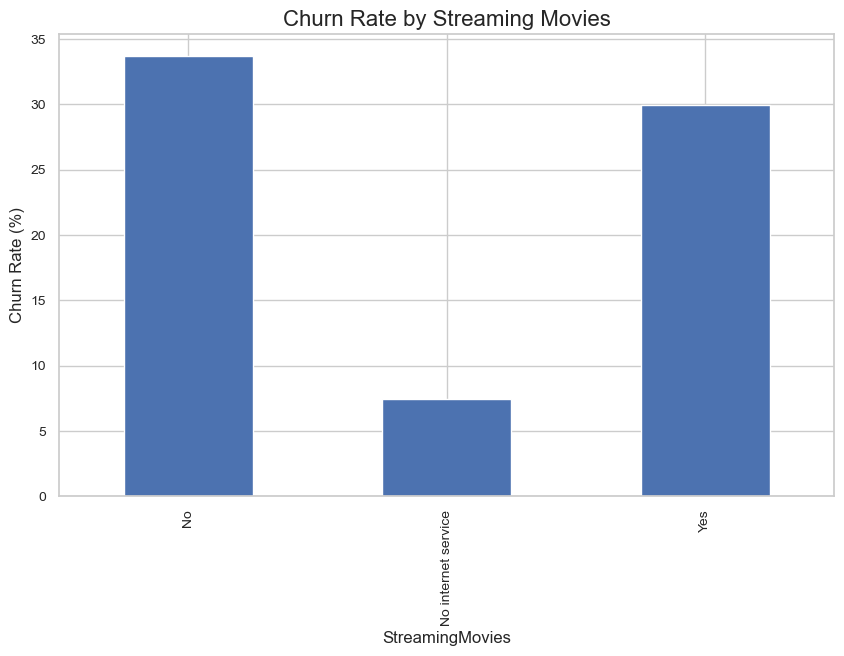

In [100]:
streamingmovies_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by Streaming Movies"
)
plt.xlabel("StreamingMovies")
plt.ylabel("Churn Rate (%)")
plt.show()

Customers who do not stream movies tend to churn slightly more.

In [65]:
paymentmethod_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
print(paymentmethod_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


### 3.3 Payment Method Distribution

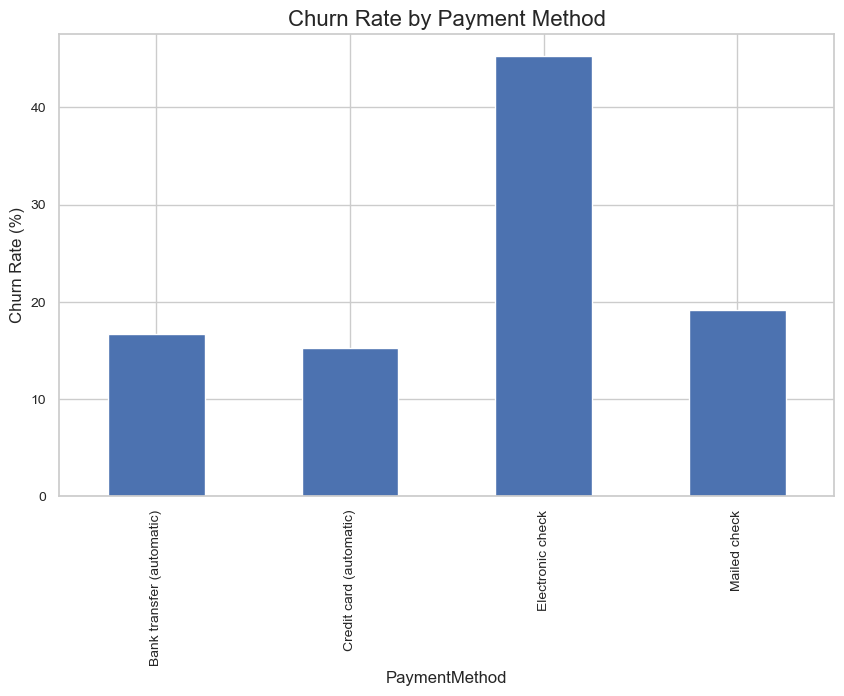

In [101]:
paymentmethod_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by Payment Method"
)
plt.xlabel("PaymentMethod")
plt.ylabel("Churn Rate (%)")
plt.show()

Customers using electronic checks have a substantially higher churn rate than customers using the other payment methods.

In [67]:
senior_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100
print(senior_churn)

Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


In [69]:
partner_churn = pd.crosstab(df["Partner"], df["Churn"], normalize="index") * 100
print(partner_churn)

Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903


In [70]:
dependents_churn = pd.crosstab(df["Dependents"], df["Churn"], normalize="index") * 100
print(dependents_churn)

Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


In [71]:
paperlessbillings_churn = pd.crosstab(df["PaperlessBilling"], df["Churn"], normalize="index") * 100
print(paperlessbillings_churn)

Churn                    No        Yes
PaperlessBilling                      
No                83.669916  16.330084
Yes               66.434908  33.565092


In [73]:
gender_churn = pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100
print(gender_churn)

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


In [74]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

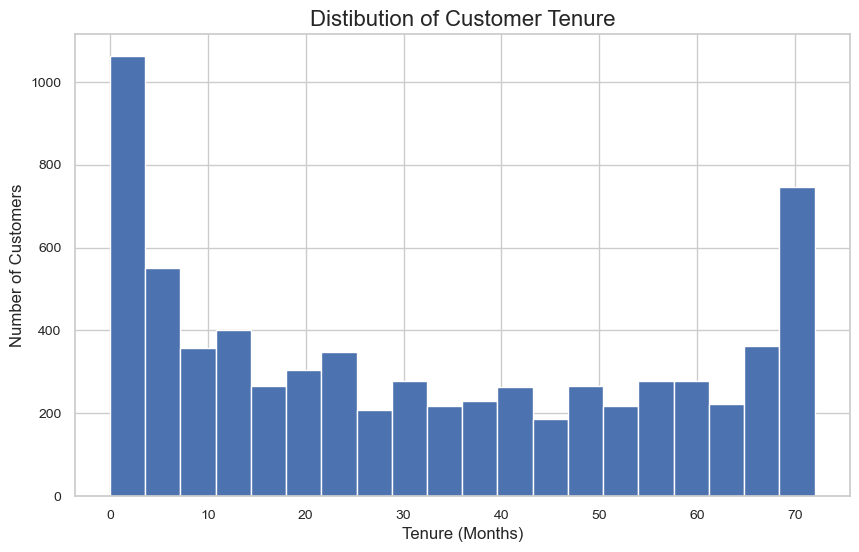

In [102]:
plt.hist(df["tenure"], bins=20)
plt.title("Distibution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

The tenure distribution shows that customers are concentrated at relatively short tenure periods, with some individual tenure values containing considerably more customers than others.

In [77]:
bins = [0, 12, 24, 48, 72]
labels = [
    "0-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins = bins,
    labels = labels,
    include_lowest=True
)

In [78]:
df["TenureGroup"].value_counts()

TenureGroup
49-72 months    2239
0-12 months     2186
25-48 months    1594
13-24 months    1024
Name: count, dtype: int64

In [80]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize = "index"
) * 100

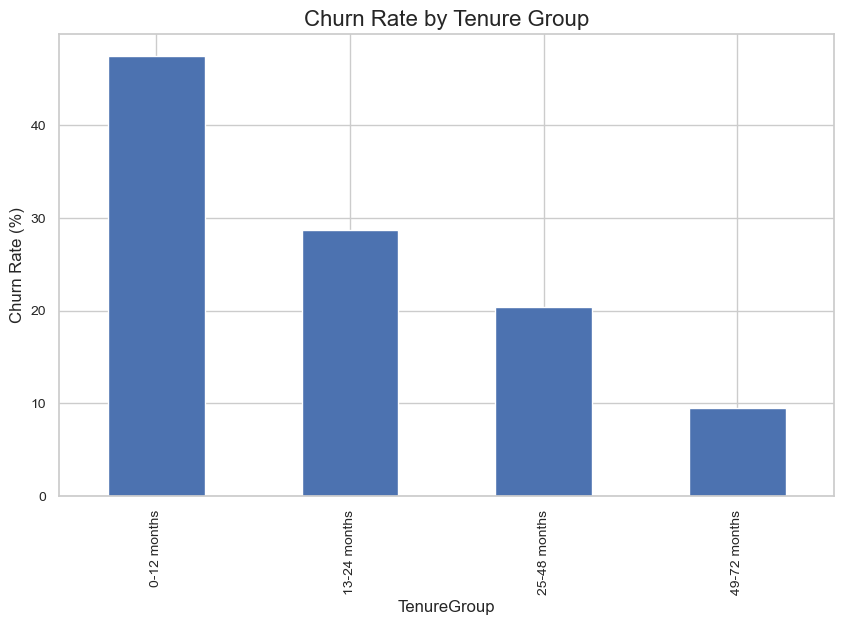

In [103]:
tenure_churn["Yes"].plot(
    kind="bar",
    title="Churn Rate by Tenure Group"
)
plt.xlabel("TenureGroup")
plt.ylabel("Churn Rate (%)")
plt.show()

The 0-12 month tenure group has the highest churn rate, indicating that newer customers are more likely to churn than customers who have remained with the company for longer periods. This suggests that the early stage of the customer relationship is a critical retention period.

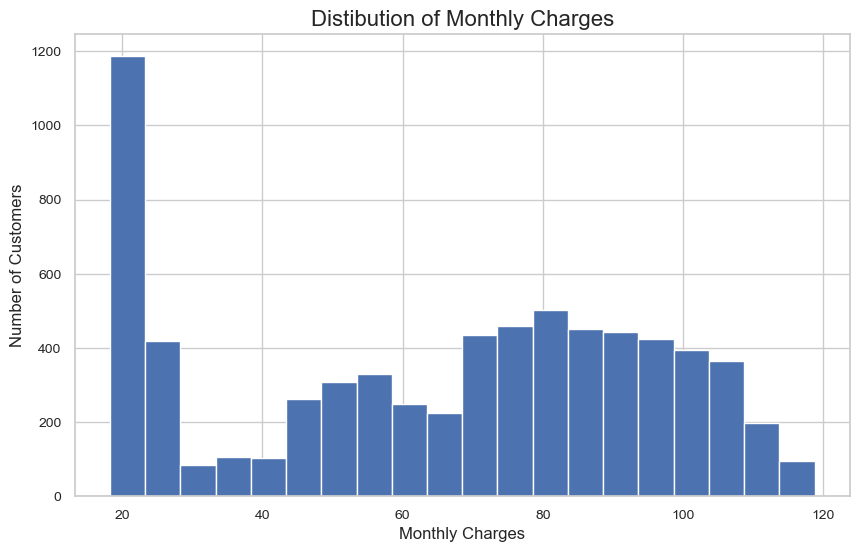

In [104]:
plt.hist(df["MonthlyCharges"], bins=20)
plt.title("Distibution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

The distribution helps establish the overall pricing profile of the customer base and provides context for comparing monthly charges between customers who churn and those who remain.

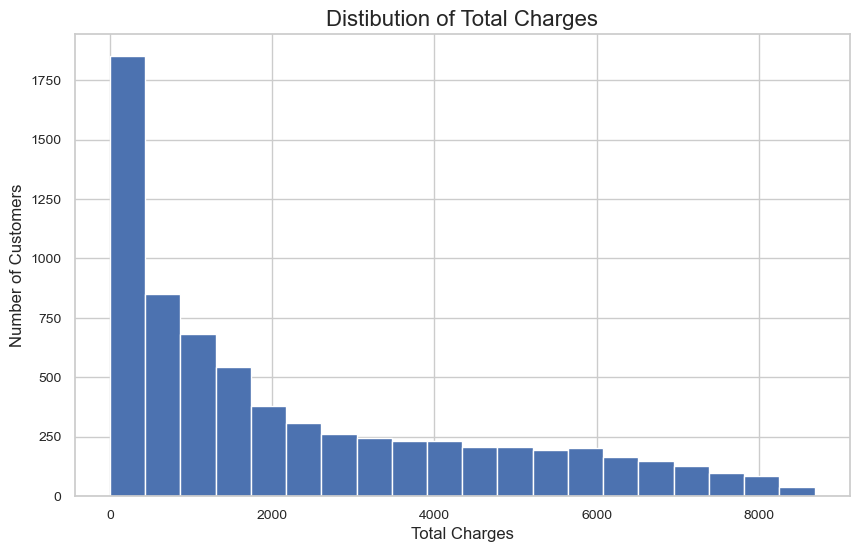

In [105]:
plt.hist(df["TotalCharges"], bins=20)
plt.title("Distibution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.show()

A large number of customers have relatively low TotalCharges values. This is consistent with the presence of many customers with short tenure, since TotalCharges represents the cumulative amount charged over the customer's relationship with the company.

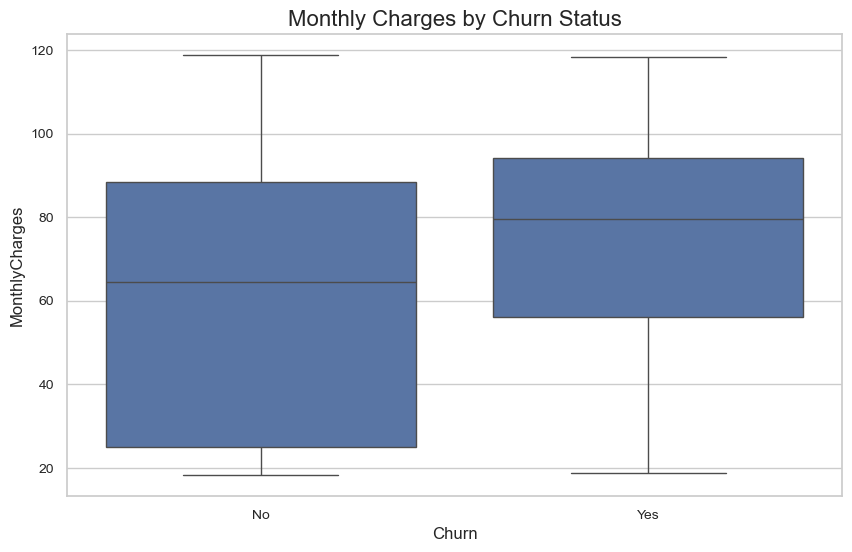

In [106]:
sns.boxplot(
    data = df,
    x = "Churn",
    y = "MonthlyCharges"
)
plt.title("Monthly Charges by Churn Status")
plt.show()

The box plot compares the distribution of MonthlyCharges between customers who churned and those who remained. The boxes show the central portion of each group's charge distribution, while the median indicates the typical charge level within each group. Differences in the position and spread of the two distributions suggest that monthly charges may be associated with churn. However the box plot alone cannot establish that higher monthly charges cause customers to leave.

In [86]:
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]
correlation = df[numeric_cols].corr()
correlation

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


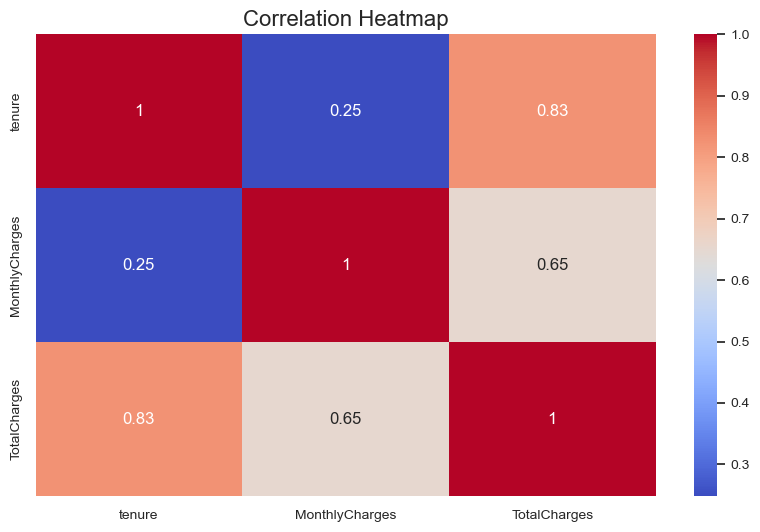

In [107]:
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

The strongest relationship is between tenure and TotalCharges, with a correlation of approximately 0.83. This is expected because TotalCharges accumulates over the duration of a customer's relationship with the company.

In [122]:
df.to_csv("telco_churn_clean.csv", index=False)

## **Key Business Insights**

1. Month-to-month customers form about 55% of the base and have the highest churn rate.
2. The 0–12 month tenure segment has the highest churn, highlighting early-life retention risk.
3. Fiber optic customers show substantially higher churn in this dataset.
4. Customers without Online Security, Online Backup, Device Protection and Tech Support show higher churn.
5. Electronic check customers show substantially higher churn than other payment groups.




## **Business Risk**

1. Continued early-life churn.
2. Heavy exposure among month-to-month customers.
3. Elevated churn in fiber/electronic-check segments.

## **Business Opportunities**

1. Strengthen onboarding.
2. Convert suitable customers to longer contracts.
3. Improve service/support adoption.
4. Use payment behaviour and service configuration to prioritize retention outreach.
   

## **Recommendations**

1. Launch an early-life retention programme focused on customers in their first 12 months.
2. Create targeted incentives for suitable month-to-month customers to move to longer contracts.
3. Investigate fiber-optic churn through pricing, network quality, complaints and onboarding data.
4. Promote relevant support/security/protection bundles and measure their effect on retention.
5. Review the electronic-check payment journey and encourage reliable alternative payment methods where appropriate.
6. Establish a recurring churn dashboard and monitor churn by tenure, contract, service and payment method.
